In [2]:
## general libraries
import numpy as np

## neural network and autograd libraries
import torch
import torch.nn as nn

## visualisation libraries
import matplotlib.pyplot as plt
import matplotlib as mpl

## plotting style, latex formatting for math, and font settings
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["font.family"] = "STIXGeneral"
mpl.rcParams.update({
    "font.size": 20,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# Analytical solution of Logistic growth model

In [3]:
## ODE parameters
r = 10
P0 = 0.01
Pmax = 1
tmax = 1

In [4]:
## Logistic growth model solution
def logistic_growth_analytical(t, r, P0, Pmax):
    P_t = Pmax * P0 * np.exp(r * t) / (Pmax + P0 * (np.exp(r * t) - 1))
    return P_t

In [5]:
## observations
P_obs = [logistic_growth_analytical(t, r, P0, Pmax) for t in np.linspace(0, tmax, 50)]

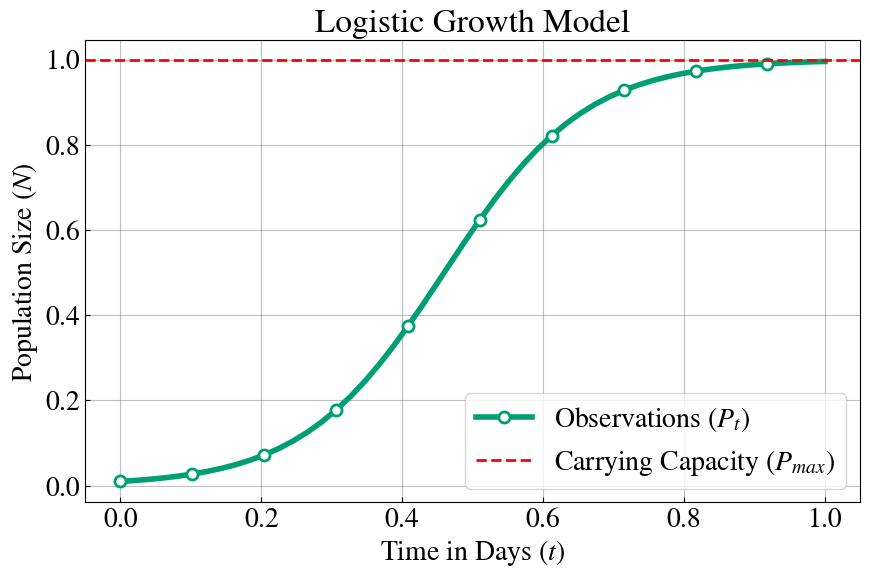

In [6]:
plt.figure(figsize=(10,6))
plt.plot(np.linspace(0, tmax, 50), P_obs, label='Observations $(P_{t})$',
         linewidth=4, color="#009E73",
         marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2, markeredgecolor="#009E73",
         markevery=5)
plt.axhline(Pmax, color='red', linestyle='--', linewidth=2, label='Carrying Capacity $(P_{max})$')
plt.xlabel('Time in Days ($t$)')
plt.ylabel('Population Size ($N$)')
plt.title('Logistic Growth Model')
plt.grid(linestyle='-', color='gray', alpha=0.5)
plt.legend()
plt.show()

# PINNs for logistic growth model

## PINNs architecture

In [7]:
torch.autograd.set_detect_anomaly(True) # Enable anomaly detection for autograd to help identify issues in the computational graph

class PINN1(nn.Module):
    ## A simple feedforward neural network with customizable architecture
    def __init__(self, input_dim, output_dim, hidden_layers=5, hidden_neurons=10, activation=nn.Tanh, r0 = 10):
        super().__init__()

        ## make a initial layer and activation function (Introduction)
        layers = []
        layers.append(nn.Linear(input_dim, hidden_neurons))
        layers.append(activation())

        ## create the remaining hidden layers with activation function (Body)
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_neurons, hidden_neurons))
            layers.append(activation())

        ## create the output layer (Conclusion)
        layers.append(nn.Linear(hidden_neurons, output_dim))

        ## combine all layers into a sequential model
        self.model = nn.Sequential(*layers)

        ## apply custom weight initialization
        self.apply(self._init_weights)

        ## parameter estimation
        self.r = nn.Parameter(torch.tensor(r0, dtype= torch.float32))
        # self.Pmax = nn.Parameter(torch.tensor(0.1, dtype= torch.float32))

    def _init_weights(self, m):
        ## Custom weight initialization for linear layers
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight, gain=0.3)
            nn.init.zeros_(m.bias)
            if m.out_features == 1:
                m.weight.data *= 0.1

    def forward(self, x):
        ## Forward pass through the network
        return self.model(x)

## ODE loss function

In [8]:
## PINN loss function based on the logistic growth ODE
def f(x, model, r, Pmax):
# def f(x, model, Pmax):
    x = x.detach().clone().requires_grad_(True) ## Ensure x is a leaf tensor with gradients enabled for autograd
    p = model(x) ## Predict population size at time x using the PINN model
    r_pred = model.r
    ## Compute the time derivative of the predicted population size using autograd (dp/dt)
    dp_dt = torch.autograd.grad(
        outputs=p,
        inputs=x,
        grad_outputs=torch.ones_like(p),
        create_graph=True,
        retain_graph=True
    )[0]

    ## The logistic growth ODE residual: dp/dt - r * p * (1 - p / Pmax)
    return dp_dt - r_pred * p * (1 - p / Pmax)

## PINNs training data

In [9]:
# Data points with observations
x_train = np.linspace(0, 1, len(P_obs)).reshape(-1, 1)
y_train = np.array(P_obs).reshape(-1, 1)

x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train).float()

# Collocation points for ODE residual for which we do not have observations but want to enforce the ODE
x_collocation = np.linspace(0, 1, 100).reshape(-1, 1)
x_collocation_tensor = torch.from_numpy(x_collocation).float()


## PINNs training

In [ ]:
r0 = 1
# Model
model = PINN1(
    input_dim=1,
    output_dim=1,
    hidden_layers=15,
    hidden_neurons=20,
    activation=nn.Tanh,
    r0 = r0
)

## Optimizer
optimizer = torch.optim.Adam(model.parameters(),
                            lr=0.001)


## Training loop
epochs = 5000
total_loss_ls = []
loss_data_ls = []
loss_ode_ls = []
r_pred_ls = []

for epoch in range(epochs):
    optimizer.zero_grad()

    pred = model(x_train_tensor)
    loss_data = torch.mean((pred - y_train_tensor) ** 2)

    res = f(x_collocation_tensor, model, r, Pmax)
    # res = f(x_collocation_tensor, model,Pmax)
    loss_ode = torch.mean(res ** 2)
    loss = loss_data + 0.1 * loss_ode

    loss.backward()
    optimizer.step()

    total_loss_ls.append(loss.item())
    loss_data_ls.append(loss_data.item())
    loss_ode_ls.append(loss_ode.item())
    r_pred_ls.append(model.r.item())


In [ ]:

plt.figure()
plt.plot(r_pred_ls, label=f"Initial r = {r0}")
plt.xlabel("Epochs")
plt.ylabel("Predicted $r$")
plt.legend()

## PINNs loss curves

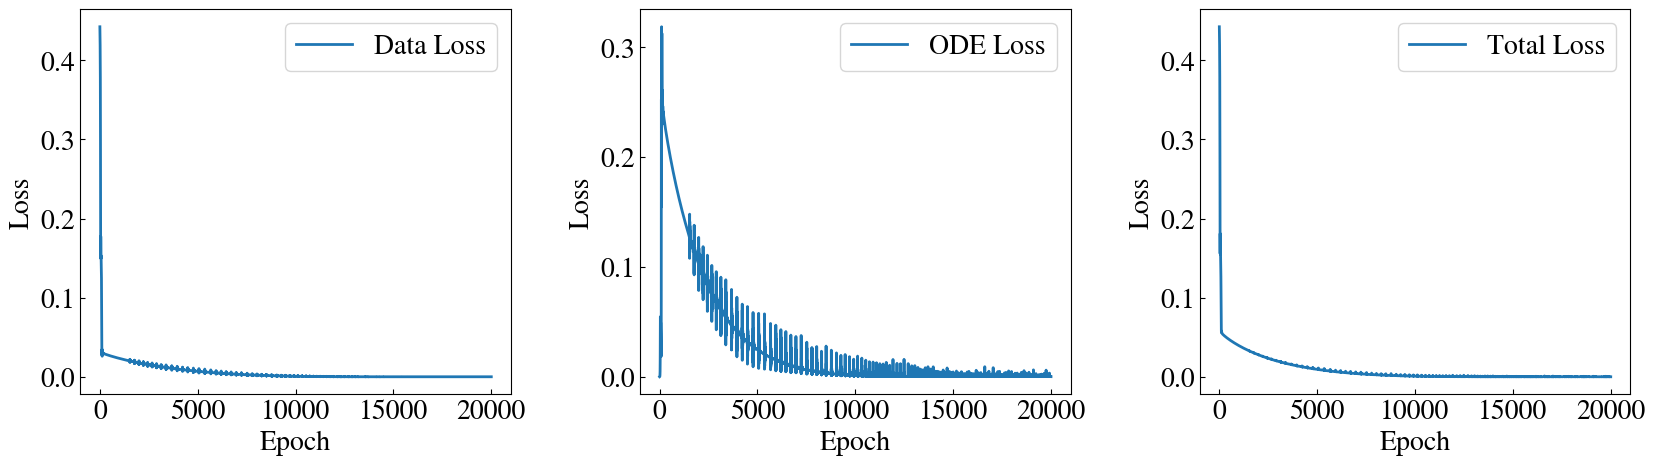

In [26]:
## Plotting the loss curves
plt.figure(figsize=(20,5))
plt.subplots_adjust(wspace=0.3)
plt.subplot(1,3,1)
plt.plot(loss_data_ls, label='Data Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(loss_ode_ls, label='ODE Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(total_loss_ls, label='Total Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


# PINNs solution vs analytical solution

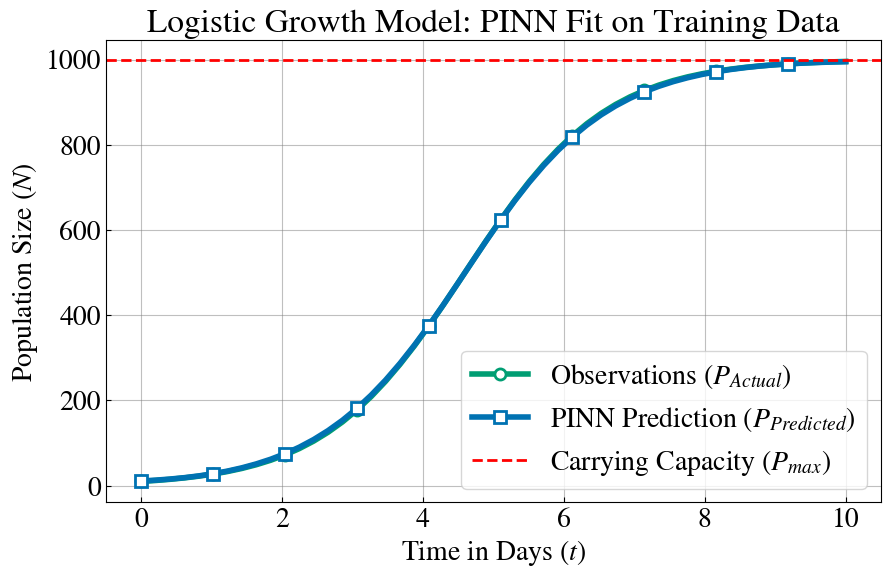

In [20]:
P_pred = model(x_train_tensor).detach().numpy()
plt.figure(figsize=(10,6))
plt.plot(x_train*10, y_train*1000, label='Observations $(P_{Actual})$',
         linewidth=4, color="#009E73",
         marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2, markeredgecolor="#009E73",
         markevery=5)
plt.plot(x_train*10, P_pred*1000, label='PINN Prediction $(P_{Predicted})$',
         linewidth=4, color="#0072B2",
         marker='s', markersize=8, markerfacecolor='white', markeredgewidth=2, markeredgecolor="#0072B2",
         markevery=5)
plt.axhline(Pmax*1000, color='red', linestyle='--', linewidth=2, label='Carrying Capacity $(P_{max})$')
plt.xlabel('Time in Days ($t$)')
plt.ylabel('Population Size ($N$)')
plt.legend()
plt.title('Logistic Growth Model: PINN Fit on Training Data')
plt.grid(linestyle='-', color='gray', alpha=0.5)

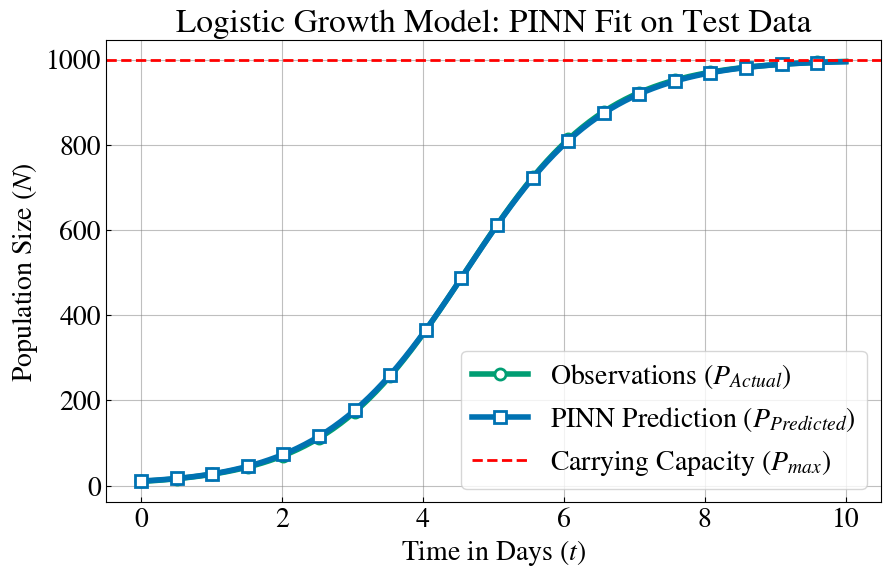

In [21]:
x_test = np.linspace(0, tmax, 100).reshape(-1, 1)
P_obs_test = [logistic_growth_analytical(t, r, P0, Pmax)*1000 for t in np.linspace(0, tmax, 100)]
x_test_tensor = torch.from_numpy(x_test).float()
P_pred_test = model(x_test_tensor).detach().numpy()

plt.figure(figsize=(10,6))
plt.plot(x_test*10, P_obs_test, label='Observations $(P_{Actual})$',
         linewidth=4, color="#009E73",
         marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2, markeredgecolor="#009E73",
         markevery=5)
plt.plot(x_test*10, P_pred_test*1000, label='PINN Prediction $(P_{Predicted})$',
         linewidth=4, color="#0072B2",
         marker='s', markersize=8, markerfacecolor='white', markeredgewidth=2, markeredgecolor="#0072B2",
         markevery=5)
plt.axhline(Pmax*1000, color='red', linestyle='--', linewidth=2, label='Carrying Capacity $(P_{max})$')
plt.xlabel('Time in Days ($t$)')
plt.ylabel('Population Size ($N$)')
plt.legend()
plt.title('Logistic Growth Model: PINN Fit on Test Data')
plt.grid(linestyle='-', color='gray', alpha=0.5)